## Pima Indians Diabetes Case study

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import(
    accuracy_score,
    roc_curve,
    confusion_matrix,
    roc_auc_score)

import statsmodels.stats.api as sms
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

## Read the data

In [3]:
data = pd.read_csv('pima-indians-diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
data.shape

(768, 9)

In [5]:
data.isnull().sum()

Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Class            0
dtype: int64

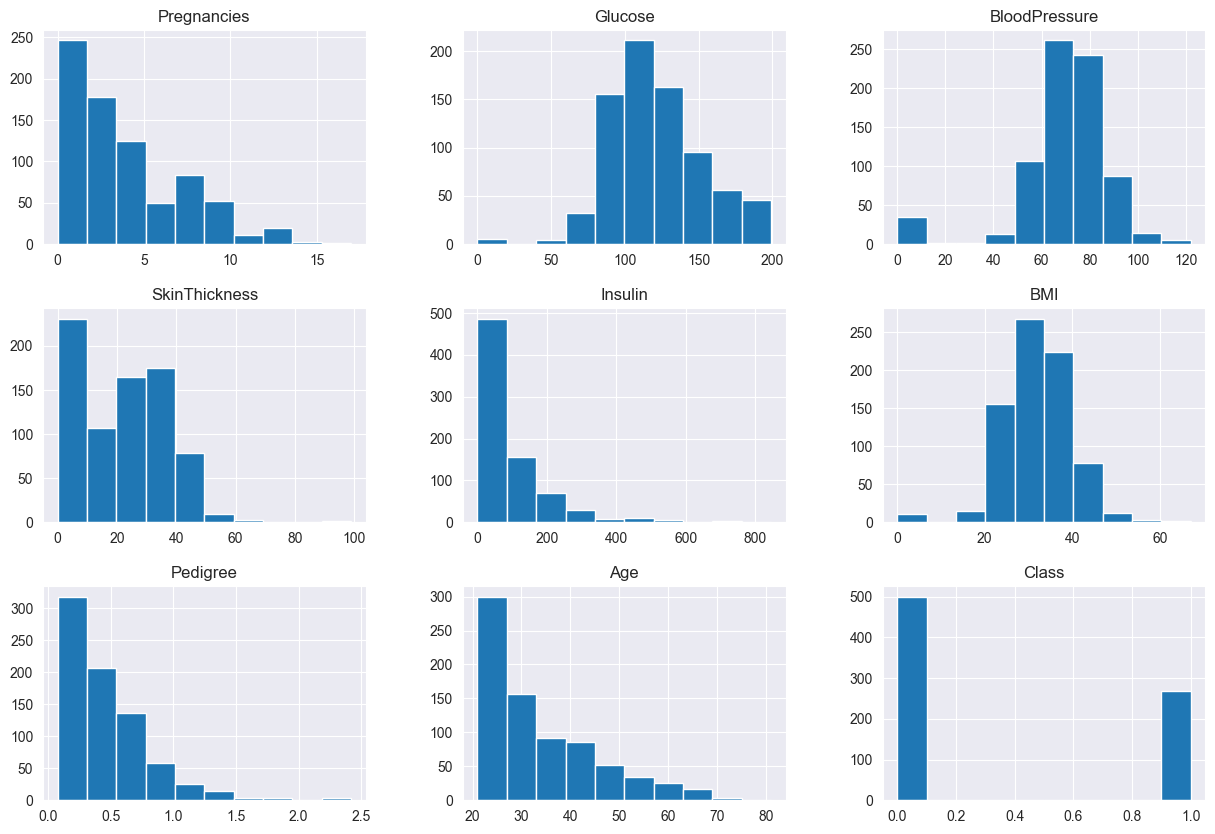

In [6]:
sns.set_style('darkgrid')
data.hist(figsize=(15,10))
plt.show()

* There are 0 values in the data that need to be cleaned

In [12]:
# list of columns to clean the 0s
cols = ['Glucose','BloodPressure','SkinThickness',
        'Insulin','BMI','Pedigree']

In [13]:
# change )s to NaN
data[cols] = data[cols].replace(0, np.nan)

In [14]:
# lots of NaN values now
data.isna().sum()

Pregnancies        0
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Pedigree           0
Age                0
Class              0
dtype: int64

In [15]:
# update the NaNs with mean values of each column
data[cols]=data[cols].fillna(data[cols].mean())

In [16]:
data.isna().mean()

Pregnancies      0.0
Glucose          0.0
BloodPressure    0.0
SkinThickness    0.0
Insulin          0.0
BMI              0.0
Pedigree         0.0
Age              0.0
Class            0.0
dtype: float64

## Bivariate Analysis

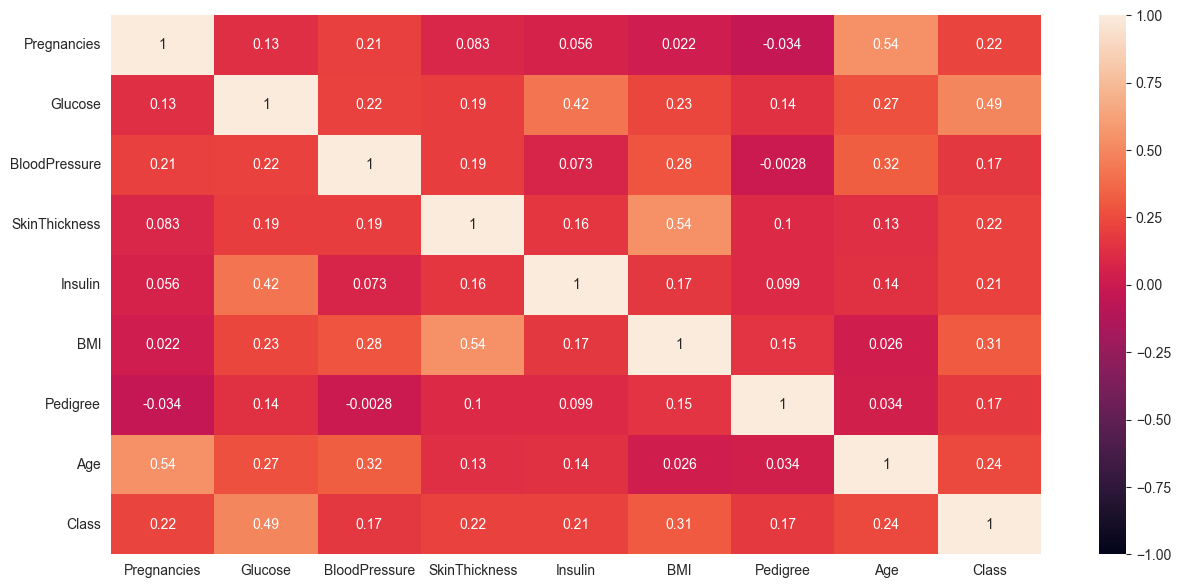

In [18]:
plt.figure(figsize=(15,7))
sns.heatmap(data.corr(),
            annot=True,
            vmin=-1,
            vmax=1)
plt.show()

* There are no strong correlations

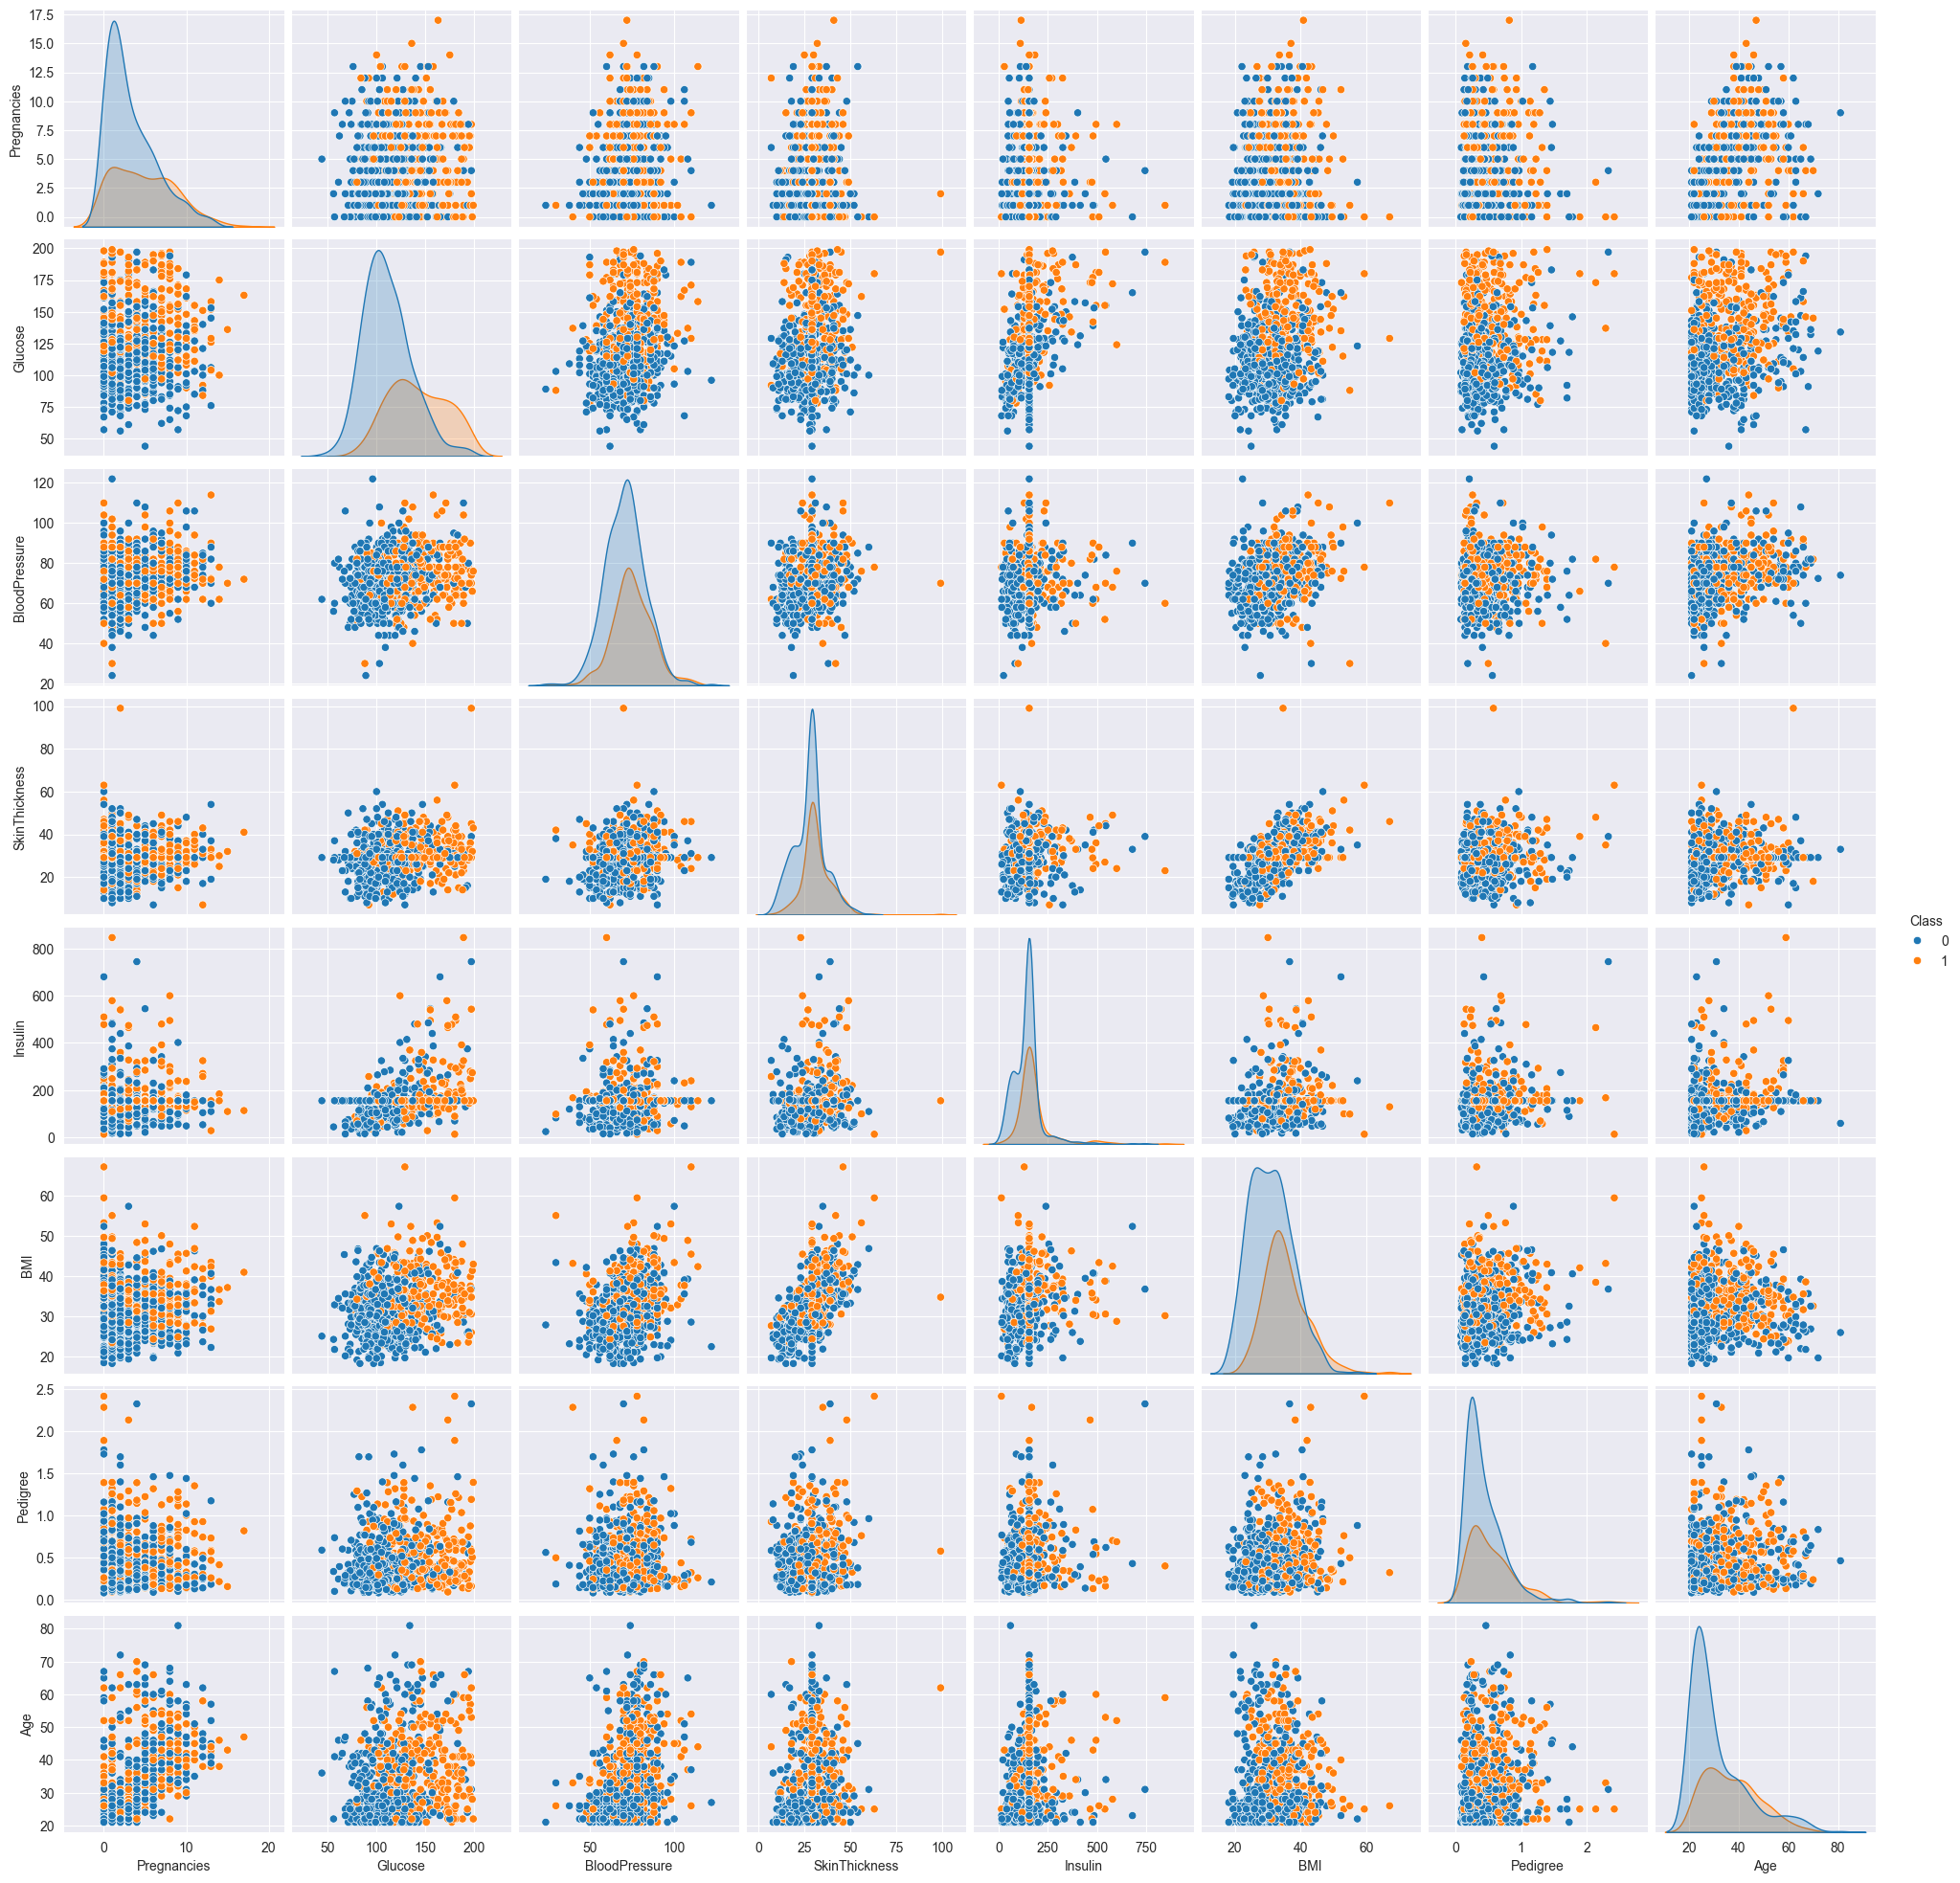

In [19]:
sns.pairplot(data,hue='Class')
plt.show()

In [21]:
data['Class'].value_counts()

Class
0    500
1    268
Name: count, dtype: int64

In [22]:
# Get the percentage split
data['Class'].value_counts(normalize=True)

Class
0    0.651042
1    0.348958
Name: proportion, dtype: float64

## Split data into train and test

In [29]:
X = data.drop(['Class'], axis=1)
y = data['Class']

X = add_constant(X)
X = pd.get_dummies(X, drop_first=True)
(X_train, X_test,
 y_train, y_test) = train_test_split(X,
                                     y,
                                     test_size=0.3,
                                     random_state=1,
                                     stratify=None)

In [63]:
y_train.shape, y_test.shape

((537,), (231,))

In [64]:
# check to make sure the 0/1 was also split 70/30
s_train = y_train[(y_train==0)].count()
s_test = y_test[(y_test)==0].count()
s_all = y[(y)==0].count()
print(s_train/s_all)
print(s_test/s_all)

0.708
0.292


In [65]:
logit = sm.Logit(y_train, X_train.astype(float))
lg = logit.fit()

Optimization terminated successfully.
         Current function value: 0.481161
         Iterations 6


In [66]:
lg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      528
Method:                           MLE   Df Model:                            8
Date:                Wed, 02 Apr 2025   Pseudo R-squ.:                  0.2500
Time:                        15:54:09   Log-Likelihood:                -258.38
converged:                       True   LL-Null:                       -344.51
Covariance Type:            nonrobust   LLR p-value:                 4.330e-33
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -8.5351      0.932     -9.160      0.000     -10.361      -6.709
Pregnancies       0.0954      0.037      2.569      0.010       0.023       0.168
Glucose           0.0333      0.004      7.480      0.000       0.025       0.042
BloodPressure    -0.0116      0.010     -1.197      0.231      -0.030       0.007
SkinThickness    -0.0075      0.015     -0.505      0.614      -0.037       0.022
Insulin          -0.0004      0.001     -0.275      0.783      -0.003       0.002
BMI               0.1063      0.020      5.185      0.000       0.066       0.146
Pedigree          0.5657      0.337      1.677      0.094      -0.095       1.227
Age               0.0199      0.011      1.809      0.070      -0.002       0.041
=================================================================================
"""

## Checking performance

In [67]:
pred_train = lg.predict(X_train)>0.5
pred_train = np.round(pred_train)

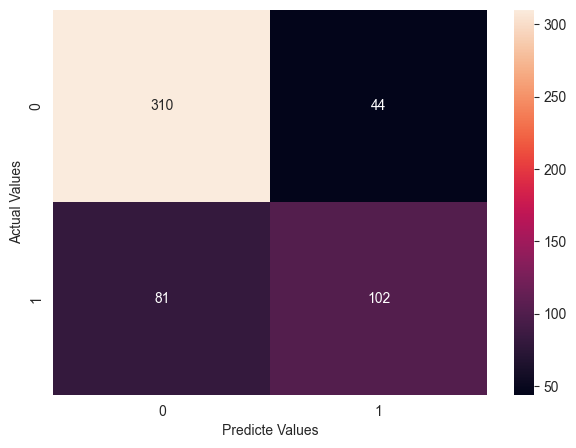

In [68]:
cm = confusion_matrix(y_train, pred_train)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicte Values')
plt.ylabel('Actual Values')
plt.show()

In [69]:
accuracy_score(y_train, pred_train)

0.7672253258845437

## Checking for multicollinearity

In [70]:
vif_series = pd.Series(
    [variance_inflation_factor(X_train.values, 
                               i) for i in range(X_train.shape[1])],
    index = X_train.columns,
    dtype=float)
vif_series

const            52.367140
Pregnancies       1.379431
Glucose           1.359795
BloodPressure     1.239773
SkinThickness     1.378737
Insulin           1.295964
BMI               1.478596
Pedigree          1.068595
Age               1.562450
dtype: float64

* None of the VIF values are above 5 or 10. No issues here

## Removing variables with p-values > 0.05

In [112]:
# Remove the high p-value one at a time and then recheck
# on each iteration. do not remove all at once
round(lg.pvalues,4)

const            0.0000
Pregnancies      0.0102
Glucose          0.0000
BloodPressure    0.2314
SkinThickness    0.6137
Insulin          0.7830
BMI              0.0000
Pedigree         0.0935
Age              0.0704
dtype: float64

In [113]:
X_train1 = X_train.drop('SkinThickness', axis=1)

In [111]:
logit1 = sm.Logit(y_train,
                  X_train1.astype(float))
lg1 = logit1.fit()
pred_train1 = lg1.predict(X_train1)
pred_train1 = np.round(pred_train1)
accuracy_score(y_train, pred_train1)

Optimization terminated successfully.
         Current function value: 0.481395
         Iterations 6


0.770949720670391

In [116]:
round(lg1.pvalues,4)

const            0.0000
Pregnancies      0.0103
Glucose          0.0000
BloodPressure    0.2422
Insulin          0.7698
BMI              0.0000
Pedigree         0.0956
Age              0.0758
dtype: float64

In [117]:
# drop insulin next
X_train2 = X_train1.drop('Insulin', axis=1)

In [118]:
logit2 = sm.Logit(y_train,
                  X_train2.astype(float))
lg2 = logit2.fit()
pred_train2 = lg2.predict(X_train2)
pred_train2 = np.round(pred_train2)
accuracy_score(y_train, pred_train2)

Optimization terminated successfully.
         Current function value: 0.481474
         Iterations 6


0.770949720670391

In [120]:
round(lg2.pvalues,4)

const            0.0000
Pregnancies      0.0105
Glucose          0.0000
BloodPressure    0.2446
BMI              0.0000
Pedigree         0.1004
Age              0.0744
dtype: float64

In [121]:
# drop blood pressure next
X_train3 = X_train2.drop('BloodPressure', axis=1)

In [123]:
logit3 = sm.Logit(y_train,
                  X_train3.astype(float))
lg3 = logit3.fit()
pred_train3 = lg3.predict(X_train3)
pred_train3 = np.round(pred_train3)
accuracy_score(y_train, pred_train3)

Optimization terminated successfully.
         Current function value: 0.482743
         Iterations 6


0.7653631284916201

In [124]:
round(lg3.pvalues,4)

const          0.0000
Pregnancies    0.0124
Glucose        0.0000
BMI            0.0000
Pedigree       0.0807
Age            0.1266
dtype: float64

In [125]:
# drop Age next
X_train4 = X_train3.drop('Age',axis=1)

In [126]:
logit4 = sm.Logit(y_train,
                  X_train4.astype(float))
lg4 = logit4.fit()
pred_train4 = lg4.predict(X_train4)
pred_train4 = np.round(pred_train4)
accuracy_score(y_train, pred_train4)

Optimization terminated successfully.
         Current function value: 0.484894
         Iterations 6


0.7579143389199255

In [127]:
lg4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      532
Method:                           MLE   Df Model:                            4
Date:                Wed, 02 Apr 2025   Pseudo R-squ.:                  0.2442
Time:                        16:52:58   Log-Likelihood:                -260.39
converged:                       True   LL-Null:                       -344.51
Covariance Type:            nonrobust   LLR p-value:                 2.482e-35
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -8.6790      0.805    -10.777      0.000     -10.257      -7.101
Pregnancies     0.1205      0.032      3.768      0.000       0.058       0.183
Glucose         0.0334      0.004      8.294      0.000       0.026       0.041
BMI             0.0933      0.017      5.437      0.000       0.060       0.127
Pedigree        0.5961      0.333      1.791      0.073      -0.056       1.249
===============================================================================
"""

### calculate odds from the lg4 coefficients

In [128]:
odds = np.exp(lg4.params)
pd.DataFrame(odds, X_train4.columns, columns=['odds']).T

,const,Pregnancies,Glucose,BMI,Pedigree
odds,0.00017,1.128014,1.033957,1.097841,1.815107


### Percentage change in odds

In [129]:
perc_change_odds = (np.exp(lg4.params)-1)*100
pd.DataFrame(perc_change_odds,
             X_train4.columns,
             columns=['Change odds%']).T

,const,Pregnancies,Glucose,BMI,Pedigree
Change odds%,-99.982987,12.801416,3.395744,9.784136,81.510688


## Performance metrics of final Lg4 model

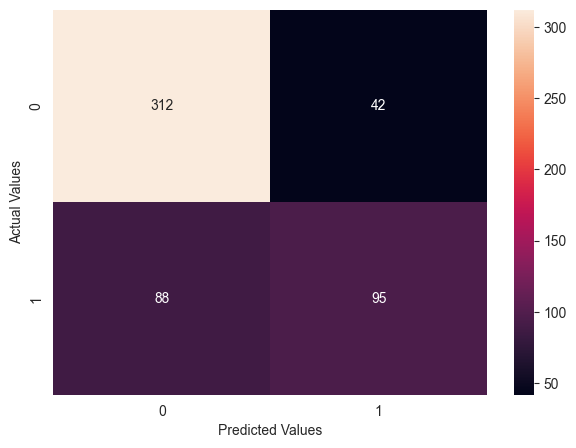

In [130]:
cm = confusion_matrix(y_train, pred_train4)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

### Accuracy on training set

In [131]:
accuracy_score(y_train, pred_train4)

0.7579143389199255

### ROC-AUC on training set

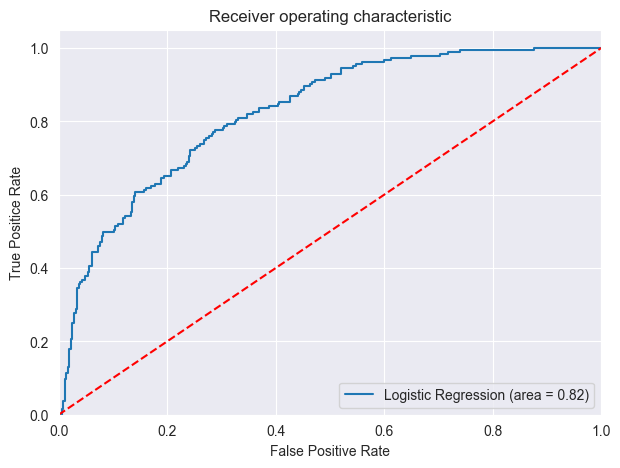

In [136]:
logit_roc_auc_train = roc_auc_score(y_train,
                                    lg4.predict(X_train4))
fpr, tpr, thresholds = roc_curve(y_train,
                                 lg4.predict(X_train4))
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, 
         label='Logistic Regression (area = %0.2f)' % logit_roc_auc_train)
plt.plot([0,1],[0,1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positice Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc='lower right')
plt.show()

### Make predictions

In [137]:
X_test = X_test.drop(['SkinThickness',
                      'BloodPressure',
                      'Insulin',
                      'Age'], axis=1)

In [138]:
pred_test = lg4.predict(X_test) > 0.5
pred_test = np.round(pred_test)

In [139]:
print("Accuracy on training set : ", accuracy_score(y_train, pred_train4))
print("Accuracy on test set : ", accuracy_score(y_test, pred_test))

Accuracy on training set :  0.7579143389199255
Accuracy on test set :  0.7922077922077922
